In [34]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
from scipy import constants
import math

In [35]:
sim = Simulation("ChargeDiffusion")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]
workDir = os.environ["PLATO_WORKDIR"]

sim["ObservingParameters/NumExposures"] = 1
dim = 9
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

# One full-frame exposure

sim["CCD/IncludeConvolution"] = "no"
sim["PSF/Model"] = "MappedGaussian"

ccdCode = '2'
sim["CCD/Position"] = ccdCode

pixelSize = sim["CCD/PixelSize"] * constants.micro / constants.milli

ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

ra = math.degrees(ra)
dec = math.degrees(dec)

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

myFile = open(starCatalogFilename, "w")
myFile.write("# RA DEC Vmag starID\n")
myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, 12.5, 1))
myFile.close()

sim["ControlHDF5Content/WriteSubPixelImages"] = True

In [36]:
sim["CCD/IncludeConvolution"] = "yes"
sim["PSF/Model"] = "MappedGaussian"

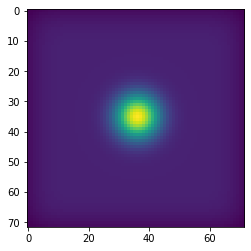

In [37]:
imageWithoutCD = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithoutCD)

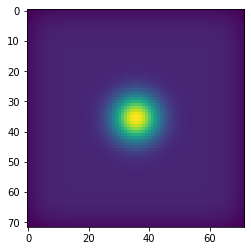

In [38]:
sim["PSF/MappedGaussian/IncludeChargeDiffusion"] = "yes"
imageWithCD = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithCD)

In [52]:
dim = dim * sim["SubField/SubPixels"]

sigma = sim["PSF/MappedGaussian/Sigma"]
params = fitGaussian2D(imageWithoutCD, np.max(imageWithoutCD), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3])
print("vs.", sigma)

Sigma: 0.639
vs. 0.639


In [53]:
sigma = math.sqrt(math.pow(sim["PSF/MappedGaussian/Sigma"], 2) + math.pow(sim["PSF/MappedGaussian/ChargeDiffusionStrength"], 2))
params = fitGaussian2D(imageWithoutCD, np.max(imageWithoutCD), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3])
print("vs.", sigma)

Sigma: 0.6695677710284449
vs. 0.6695677710284449
